In [1]:
!pip install Sastrawi
!pip install tensorflow
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import string
import json
import pickle
import tensorflow as tf
import time
import matplotlib.pyplot as plt
import seaborn as sns

from google import genai
from groq import Groq
from google.colab import userdata
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.utils import compute_class_weight
from tensorflow.keras.layers import (TextVectorization, Embedding, LSTM, Dense, Dropout, Layer)
from tensorflow.keras.utils import plot_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Model #untuk functional API
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

**MODEL LLM**

In [3]:
client = Groq(api_key=userdata.get('GROQ_API_KEY'))


def llm_clean(teks: str) -> str:
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "system",
                    "content": """Kamu adalah normalisasi teks untuk aplikasi pencatatan keuangan Indonesia.
Tugasmu: ubah deskripsi transaksi menjadi frasa Bahasa Indonesia yang sederhana dan umum.
Aturan:
- Hapus nama orang dan nama tempat spesifik
- Ganti nama brand/aplikasi asing dengan kategori umumnya dalam Bahasa Indonesia
- Pertahankan makna aslinya, jangan ubah konteks transaksi
- Hasil harus 2-5 kata saja, Bahasa Indonesia
- Jangan tambahkan penjelasan, langsung tulis hasilnya saja

Contoh:
- "makan ayam bakar di warung pak balil" → "makan ayam bakar"
- "beli netflix bulanan" → "langganan hiburan streaming"
- "top up gopay" → "isi saldo dompet digital"
- "bensin di SPBU Pertamina Batam" → "beli bahan bakar"
- "bayar kosan cibaduyut" -> "bayar tagihan kosan
- "bayar kost bu Endah" → "bayar tempat tinggal" """
                },
                {
                    "role": "user",
                    "content": teks
                }
            ],
            temperature=0.1,
            max_tokens=50,
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        print(f"[LLM] Error: {e}, pakai teks asli")
        return teks

In [4]:
url = "https://raw.githubusercontent.com/Capstone-Catatanku/Data-Science/refs/heads/main/Data-clean/Data-clean.csv"
data = pd.read_csv(url)
data = data[data['deskripsi_transaksi'].str.split().str.len() >= 2].reset_index(drop=True)
print(f"Total data bersih: {len(data)}")
print()
print(data['kategori'].value_counts())



Total data bersih: 37289

kategori
Belanja         8490
Konsumsi        7819
Tagihan         4673
Transportasi    4358
Kesehatan       3443
Hiburan         2894
Lain-lain       2821
Investasi       1470
Pendapatan      1321
Name: count, dtype: int64


In [5]:
data.head()

,tanggal,deskripsi_transaksi,kategori,nominal
0,2023-12-17,tagihan gas 3kg melon ijo lagi rusak mendadak,Tagihan,14171.0
1,2021-06-13,jajan rames ayam pop deket kosan,Konsumsi,131000.0
2,2023-03-14,saham tlkm telkom fundamental kuat,Investasi,86150.0
3,2023-01-07,renovasi keperluan cairan karbol wipol,Tagihan,22932.0
4,2023-06-03,order mesin bor skill,Belanja,325000.0


In [6]:
data.info()
data['kategori'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37289 entries, 0 to 37288
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              37289 non-null  object 
 1   deskripsi_transaksi  37289 non-null  object 
 2   kategori             37289 non-null  object 
 3   nominal              37289 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB


,count
kategori,
Belanja,8490
Konsumsi,7819
Tagihan,4673
Transportasi,4358
Kesehatan,3443
Hiburan,2894
Lain-lain,2821
Investasi,1470
Pendapatan,1321


**Preprocessing data**

In [7]:
def preprocessing(teks):
  teks = teks.lower()
  teks = re.sub(r'[^\w\s]', "", teks)
  teks = re.sub(r'\s+', ' ', teks)
  return teks.strip()

In [8]:
slang_dict = {
    "bli": "beli", "dapet": "dapat", "tdk": "tidak",
    "byr": "bayar", "gw": "saya", "dr": "dari", "yg": "yang",
    "dgn": "dengan", "utk": "untuk", "jd": "jadi", "krn": "karena",
    "udh": "sudah", "sdh": "sudah", "msh": "masih", "bs": "bisa",
    "nyicil": "cicilan", "cicil": "cicilan", "pesen": "pesan",
    "topup": "isi saldo", "kontrakan": "sewa", "invest": "investasi", "nyaham": "saham"
}
def normalize_slang_words(teks):
    return ' '.join([slang_dict.get(w, w) for w in teks.split()])

def clean(teks):
  teks = preprocessing(teks)
  teks = normalize_slang_words(teks)
  return teks
data['deskripsi_transaksi'] = data['deskripsi_transaksi'].apply(clean)
data.head()

,tanggal,deskripsi_transaksi,kategori,nominal
0,2023-12-17,tagihan gas 3kg melon ijo lagi rusak mendadak,Tagihan,14171.0
1,2021-06-13,jajan rames ayam pop deket kosan,Konsumsi,131000.0
2,2023-03-14,saham tlkm telkom fundamental kuat,Investasi,86150.0
3,2023-01-07,renovasi keperluan cairan karbol wipol,Tagihan,22932.0
4,2023-06-03,order mesin bor skill,Belanja,325000.0


In [9]:
X = data['deskripsi_transaksi'].values
y = data['kategori'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
len(X_train), len(X_val), len(X_test)

(29831, 3729, 3729)

In [10]:
print("Distribusi kategori (training set):")
import pandas as pd
kategori_counts = pd.Series(y_train).value_counts()
print(kategori_counts)
print()
print(f"Rasio terbanyak vs tersedikit: {kategori_counts.max() / kategori_counts.min():.1f}x")

Distribusi kategori (training set):
Belanja         6792
Konsumsi        6255
Tagihan         3738
Transportasi    3486
Kesehatan       2755
Hiburan         2315
Lain-lain       2257
Investasi       1176
Pendapatan      1057
Name: count, dtype: int64

Rasio terbanyak vs tersedikit: 6.4x


**TEXT VECTORIZATION**

In [11]:
# Initialize LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

In [12]:
#pakai attention
from tensorflow.keras import Input
max_tokens = 5000
seq_length = 30

vectorize_layer = TextVectorization(
    max_tokens= max_tokens,
    output_sequence_length=seq_length
)
vectorize_layer.adapt(X_train)
vocab = vectorize_layer.get_vocabulary()
with open('vocabulary.json', 'w', encoding='utf-8') as f:
  json.dump(vocab, f, ensure_ascii=False)
num_classes = len(le.classes_)
@tf.keras.utils.register_keras_serializable()
class AttentionLayer (Layer):
  def __init__(self, **kwargs):
    super(AttentionLayer, self).__init__(**kwargs)
    self.supports_masking = True

  def build(self, input_shape):
    self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                           initializer="normal")
    super(AttentionLayer, self).build(input_shape)

  def call(self, x, mask=None):
    e = tf.matmul(x, self.W)

    if mask is not None:
        mask = tf.cast(mask, tf.float32)
        mask = tf.expand_dims(mask, -1)
        e = e + (mask - 1) * 1e9

    a = tf.nn.softmax(e, axis=1)
    output = x * a
    return tf.reduce_sum(output, axis=1)

  def compute_mask(self, inputs, mask=None):
    return None

inputs = Input(shape=(1,), dtype=tf.string)
x = vectorize_layer(inputs)
x = Embedding(input_dim=max_tokens, output_dim=64, mask_zero=True)(x)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.4)(x)
x = AttentionLayer(name='attention_layer')(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 30)        │          0 │ input_layer[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 64)    │    320,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 32)    │     12,416 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 32)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 32)        │         32 │ dropout[0][0],    │
│ (AttentionLayer)    │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9)         │        297 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 333,801 (1.27 MB)

 Trainable params: 333,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**class weight**

In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights = dict(enumerate(class_weights))
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [14]:
history = model.fit(X_train, y_train_encoded, epochs=20, callbacks=[early_stopping], class_weight=class_weights, validation_data=(X_val, y_val_encoded), batch_size=32)
print(history.history)
model.evaluate(X_test, y_test_encoded)

Epoch 1/20
933/933 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.8744 - loss: 0.4274 - val_accuracy: 0.9710 - val_loss: 0.1080
Epoch 2/20
933/933 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9742 - loss: 0.0702 - val_accuracy: 0.9697 - val_loss: 0.0988
Epoch 3/20
933/933 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9825 - loss: 0.0434 - val_accuracy: 0.9724 - val_loss: 0.1034
Epoch 4/20
933/933 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9856 - loss: 0.0344 - val_accuracy: 0.9635 - val_loss: 0.1287
Epoch 5/20
933/933 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9868 - loss: 0.0280 - val_accuracy: 0.9659 - val_loss: 0.1332
{'accuracy': [0.8743588924407959, 0.9741879105567932, 0.9824678897857666, 0.9856190085411072, 0.9867587685585022], 'loss': [0.4274114966392517, 0.07015567272901535, 0.043440092355012894, 0.034399013966321945, 0.02797265537083149], 'val_accuracy': [0.9710378050804138, 0.9696969985961914, 0.972378671169281, 0.963529109954834, 0.9659426212310791], 'va

[0.10884399712085724, 0.9683561325073242]

In [15]:
model.save('model_klasifikasi.keras')
print(" Model balanced tersimpan")

 Model balanced tersimpan


In [16]:
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(" label_encoder.pkl tersimpan")

 label_encoder.pkl tersimpan


In [17]:
X_test_tensor = tf.constant(X_test.reshape(-1, 1).tolist())
y_pred_probs = model.predict(X_test_tensor, batch_size=32)
y_pred = y_pred_probs.argmax(axis=1)
report = classification_report(y_test_encoded, y_pred)
print(report)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       849
           1       1.00      1.00      1.00       289
           2       0.99      0.96      0.97       147
           3       0.95      0.98      0.96       344
           4       0.95      0.96      0.96       782
           5       1.00      1.00      1.00       282
           6       1.00      1.00      1.00       132
           7       1.00      1.00      1.00       468
           8       0.98      0.97      0.98       436

    accuracy                           0.97      3729
   macro avg       0.98      0.98      0.98      3729
weighted avg       0.97      0.97      0.97      3729



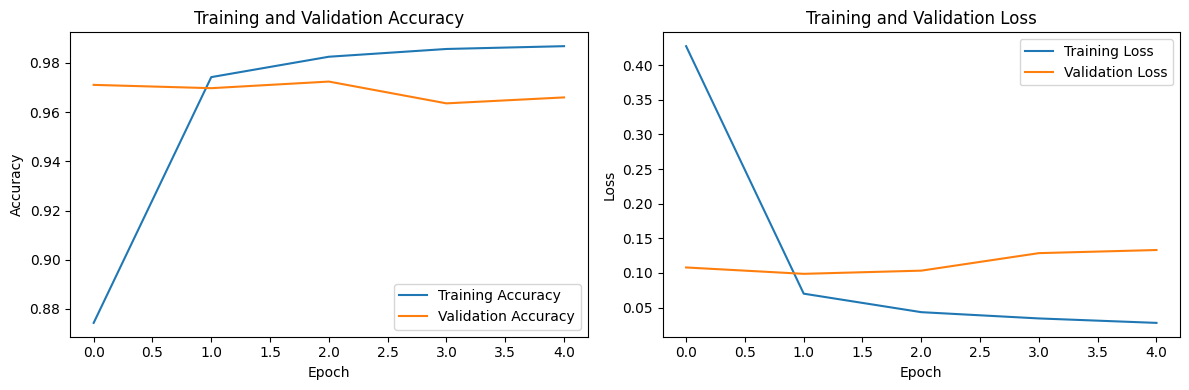

In [18]:
def plot_history(history_data):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_data.history['accuracy'], label='Training Accuracy')
    plt.plot(history_data.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_data.history['loss'], label='Training Loss')
    plt.plot(history_data.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [19]:
#INFERENCE
SLANG_DICT = {
    "bli": "beli", "dapet": "dapat", "tdk": "tidak",
    "byr": "bayar", "gw": "saya", "dr": "dari", "yg": "yang",
    "dgn": "dengan", "utk": "untuk", "jd": "jadi", "krn": "karena",
    "udh": "sudah", "sdh": "sudah", "msh": "masih", "bs": "bisa",
    "nyicil": "cicilan", "cicil": "cicilan", "pesen": "pesan",
    "topup": "isi ", "kontrakan": "sewa", "invest": "investasi", "nyaham": "saham"
}

def preprocessing(teks):
    teks = teks.lower()
    teks = re.sub(r'[^\w\s]', '', teks)
    teks = re.sub(r'\s+', ' ', teks)
    return teks.strip()

def normalize_slang_words(teks):
    return ' '.join([SLANG_DICT.get(w, w) for w in teks.split()])

def clean(teks):
    teks = preprocessing(teks)
    teks = normalize_slang_words(teks)
    return teks
with open('vocabulary.json', 'r', encoding='utf-8') as f:
    vocab = json.load(f)
vectorize_layer = TextVectorization(max_tokens=5000, output_sequence_length=30)
vectorize_layer.adapt(['dummy'])
vectorize_layer.set_vocabulary(vocab)

model = tf.keras.models.load_model('model_klasifikasi.keras', custom_objects={'AttentionLayer': AttentionLayer})

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print("Model dan LabelEncoder loaded")
print("Kategori:", list(le.classes_))

# prediksi
def split_transaksi(teks):
    parts = re.split(r',|\bdan\b|\blalu\b', teks)
    return [p.strip() for p in parts if p.strip()]

def predict_kategori(teks_mentah):
    teks_bersih = clean(teks_mentah)
    pred = model.predict(tf.constant([[teks_bersih]]), verbose=0)
    idx  = pred.argmax(axis=1)[0]
    return {
        'transaksi'  : teks_mentah,
        'bersih'     : teks_bersih,
        'kategori'   : le.inverse_transform([idx])[0],
        'confidence' : round(float(pred[0][idx]) * 100, 2),
        'semua_skor' : {le.classes_[i]: round(float(pred[0][i]) * 100, 2)
                        for i in range(len(le.classes_))}
    }

def analisis_transaksi(teks):
    return [predict_kategori(t) for t in split_transaksi(teks)]

input = "Dapet THR"

for item in analisis_transaksi(input):
    print(f"\nTransaksi : {item['transaksi']}")
    print(f"Bersih    : {item['bersih']}")
    print(f"Kategori  : {item['kategori']}  ({item['confidence']}%)")
    print("Semua skor:")
    for k, v in sorted(item['semua_skor'].items(), key=lambda x: -x[1]):
        bar = 'I' * int(v // 5)
        print(f"  {k:<20} {bar} {v}%")

Model dan LabelEncoder loaded
Kategori: ['Belanja', 'Hiburan', 'Investasi', 'Kesehatan', 'Konsumsi', 'Lain-lain', 'Pendapatan', 'Tagihan', 'Transportasi']

Transaksi : Dapet THR
Bersih    : dapat thr
Kategori  : Pendapatan  (84.51%)
Semua skor:
  Pendapatan           IIIIIIIIIIIIIIII 84.51%
  Belanja              I 7.58%
  Hiburan               2.24%
  Kesehatan             1.8%
  Tagihan               1.66%
  Konsumsi              0.98%
  Transportasi          0.63%
  Lain-lain             0.4%
  Investasi             0.19%
